1. Loading Data and Champion Model...
2. Generating Predictions to find a blocked fraud attempt...
3. Generating Global SHAP Explanations...


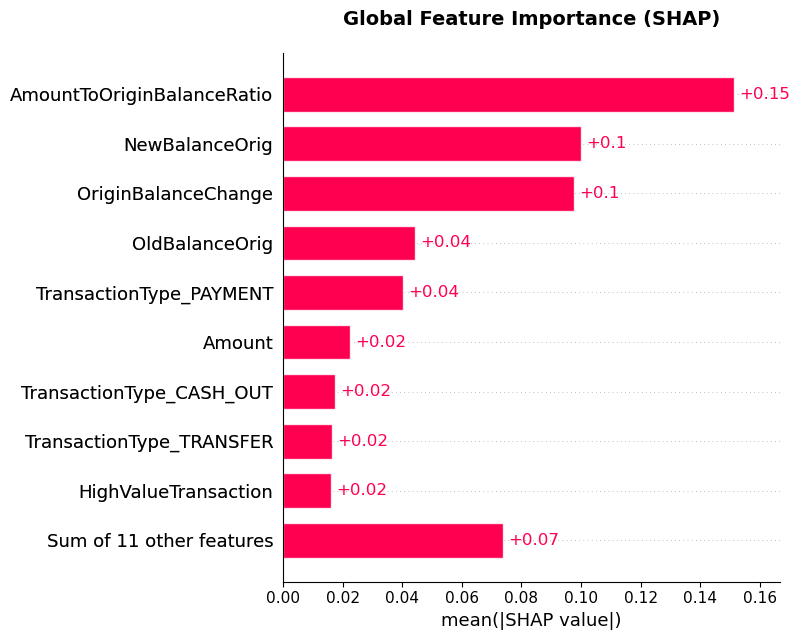

4. Generating Local SHAP Explanation for a specific fraud event...


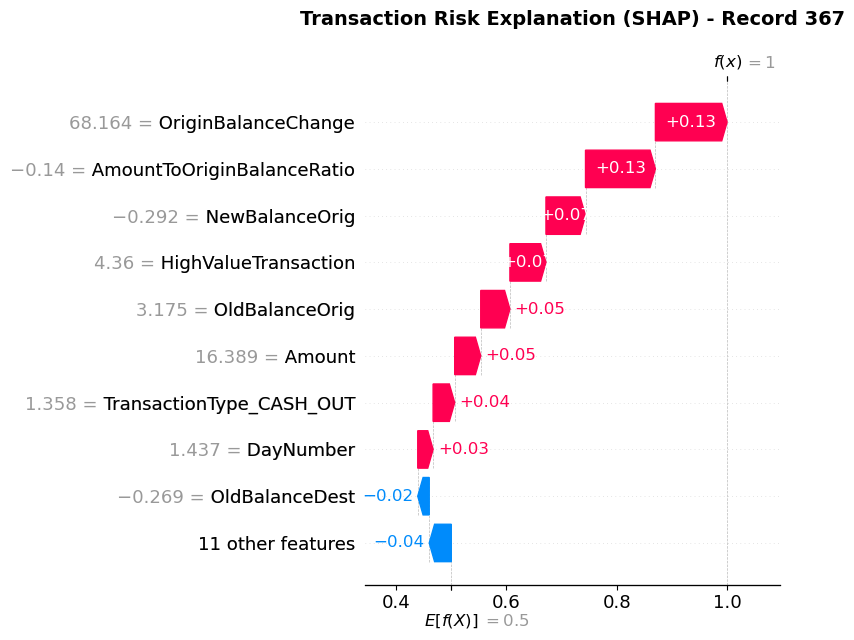

In [7]:
# ==========================================
# ENTERPRISE FINTECH PAYMENT INTELLIGENCE
# Notebook 08 - Model Explainability (SHAP)
# ==========================================

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import shap
import warnings

warnings.filterwarnings("ignore")

print("1. Loading Data and Champion Model...")

# ------------------------------------------
# THE ULTIMATE ABSOLUTE PATHS
# ------------------------------------------
data_path = "C:/Users/ANTO ABRAHAM AJ/Downloads/Enterprise_FinTech_Payment_Intelligence_Platform/04_Machine_Learning/datasets/"
model_path = "C:/Users/ANTO ABRAHAM AJ/Downloads/Enterprise_FinTech_Payment_Intelligence_Platform/04_Machine_Learning/models/" 

X_test = pd.read_csv(data_path + "X_test.csv")
y_test = pd.read_csv(data_path + "y_test.csv").values.ravel()
rf_model = joblib.load(model_path + "RandomForest_Model.pkl")

print("2. Generating Predictions to find a blocked fraud attempt...")
rf_pred = rf_model.predict(X_test)

# ==========================================
# GLOBAL FEATURE IMPORTANCE
# ==========================================
print("3. Generating Global SHAP Explanations...")

# Sample 1000 rows so it runs fast without freezing the notebook
sample = X_test.sample(1000, random_state=42)
explainer = shap.TreeExplainer(rf_model)
sample_shap = explainer(sample)

plt.figure(figsize=(10,6))
shap.plots.bar(sample_shap[:, :, 1], max_display=10, show=False)
plt.title("Global Feature Importance (SHAP)", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ==========================================
# LOCAL EXPLANATION (Waterfall Plot)
# ==========================================
print("4. Generating Local SHAP Explanation for a specific fraud event...")

# Find a true positive (a transaction correctly flagged as fraud)
fraud_indices = np.where((y_test == 1) & (rf_pred == 1))[0]
fraud_index = fraud_indices[0] 
single_transaction = X_test.iloc[[fraud_index]]

shap_values = explainer(single_transaction)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[0, :, 1], max_display=10, show=False)
plt.title(f"Transaction Risk Explanation (SHAP) - Record {fraud_index}", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
Business Summary

• SHAP improves model transparency by explaining individual fraud predictions.
• Global SHAP analysis identified balance-related variables as the strongest fraud indicators.
• Local SHAP explanations demonstrate why a specific transaction was classified as fraudulent.
• Explainable AI increases stakeholder confidence and supports fraud analyst investigations.